In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

from pathlib import Path
import os
import sys

In [2]:
# Get current file location
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    BASE_DIR = Path.cwd().parents[1]

# add src to python path
sys.path.append(str(BASE_DIR))

# Path to data folder
DATA_DIR = BASE_DIR / "data"

# load data
data_train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None)
data_test = pd.read_csv(DATA_DIR / "test_FD001.txt", sep=r"\s+", header=None)
data_rul = pd.read_csv(DATA_DIR / "RUL_FD001.txt", header=None)

# prepare name for each columns
cols = (
    ['engine_id','cycle'] +
    [f'setting_{i}' for i in range(1,4)] +
    [f'sensor_{i}' for i in range(1,22)]
)

In [3]:
#data_test = pd.concat([data_test, data_rul], axis=1)

In [4]:
data_test

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,520.69,2388.00,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,521.05,2388.09,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,521.18,2388.04,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,521.33,2388.08,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699


In [5]:
data_train

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [6]:
from src.data.preprocess import preprocess

train_pre, test_pre = preprocess(data_train, data_test, cols, clip=False)

In [7]:
print("train pre shape:", train_pre.shape, "test pre shape:", test_pre.shape)

train pre shape: (20631, 27) test pre shape: (13096, 26)


In [8]:
from src.features.build_features import build_features

train_df, test_df = build_features(train_pre, test_pre)

sensors with low variance:
sensor_1     0.000000e+00
sensor_5     3.155597e-30
sensor_6     1.929279e-06
sensor_10    0.000000e+00
sensor_16    1.926023e-34
sensor_18    0.000000e+00
sensor_19    0.000000e+00
dtype: float64


In [9]:
print("train df shape:", train_df.shape, "test df shape:", test_df.shape)

train df shape: (19731, 62) test df shape: (12196, 61)


In [10]:
# train dataset
# 1.train-val-split for machine learning
X_train = train_df.drop(columns=["RUL"])
y_train = train_df["RUL"]

groups = train_df["engine_id"]

split = GroupShuffleSplit(test_size=0.2, n_splits=1)

train_idx, val_idx = next(split.split(X_train, y_train, groups))

X_train, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_train, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

# 2.dataset for deep learning
X_train_scaled = train_df.iloc[train_idx].copy()
X_val_scaled = train_df.iloc[val_idx].copy()

# scaled data
scaler = StandardScaler()

sensor_cols = [c for c in train_df.columns if "sensor" in c]

X_train_scaled[sensor_cols] = scaler.fit_transform(X_train[sensor_cols])
X_val_scaled[sensor_cols] = scaler.transform(X_val[sensor_cols])

# Reshape into sequences
from src.features.build_features import create_sequences

X_train_seq, y_train_seq = create_sequences(X_train_scaled,seq_len=30)
X_val_seq, y_val_seq = create_sequences(X_val_scaled,seq_len=30)

# dataloader
from torch.utils.data import DataLoader
from src.model.dataset import RULDataset

train_dataset = RULDataset(X_train_seq, y_train_seq)
val_dataset = RULDataset(X_val_seq, y_val_seq)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [11]:
# test dataset
# 1.dataset for machine learning -> take last cycle per engine
test_last = test_df.groupby("engine_id").last().reset_index()

X_test = test_last.drop(columns=["RUL"], errors="ignore")
y_test = data_rul

# 2.dataset for deep learning
sensor_cols = [c for c in test_df.columns if "sensor" in c]

X_test_scaled = test_df.copy()

X_test_scaled[sensor_cols] = scaler.transform(X_test_scaled[sensor_cols])

# Reshape into sequences
from src.features.build_features import create_test_sequences

X_test_seq = create_test_sequences(X_test_scaled, seq_len=30)

# dataloader
from torch.utils.data import DataLoader
from src.model.dataset import RULDataset

test_dataset = RULDataset(X_test_seq, np.zeros(len(X_test_seq)))

test_loader = DataLoader(test_dataset, batch_size=64)

In [12]:
print("X_train_scaled shape:", X_train_scaled.shape, "X_test_scaled shape:", X_test_scaled.shape)
print("X_train_seq shape:", X_train_seq.shape, "X_test_seq shape:", X_test_seq.shape)

X_train_scaled shape: (16027, 62) X_test_scaled shape: (12196, 61)
X_train_seq shape: (13627, 30, 56) X_test_seq shape: (100, 30, 56)


In [13]:
print(np.isnan(X_train_seq).sum())
print(np.isnan(y_train_seq).sum())
print(np.isnan(X_val_seq).sum())
print(np.isnan(y_val_seq).sum())
print(np.isnan(X_test_seq).sum())
print(np.isnan(y_test).sum())

0
0
0
0
0
0    0
dtype: int64


In [14]:
data = {

    # classical ML
    "ml": {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    },

    # deep learning
    "dl": {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "X_train_seq": X_train_seq,
        "X_val_seq": X_val_seq,
        "test_loader": test_loader,
        "X_test_seq": X_test_seq
    }
}

In [15]:
print("Train seq shape:", data["dl"]["X_train_seq"].shape)
print("Test seq shape:", data["dl"]["X_test_seq"].shape)

Train seq shape: (13627, 30, 56)
Test seq shape: (100, 30, 56)


In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [17]:
config = {

    "training": {
        "epochs": 20,
        "batch_size": 64,
        "lr": 1e-3,
        "device": device
    },

    "data": {
        "input_size": X_train_seq.shape[2],   # number of sensors/features
        "window_size": X_train_seq.shape[1]
    },

    "models": {

        "xgboost": {
            "objective":"reg:squarederror",
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42
        },

        "lightgbm": {
            "objective": "regression",
            "n_estimators": 500,
            "num_leaves": 31,
            "learning_rate": 0.05,
            "random_state": 42
        },

        "lstm": {
            "hidden_size": 64,
            "num_layers": 2,
            "dropout": 0.2
        },

        "tcn": {
            "num_channels": 64,
            "kernel_size": 3
        },

        "transformer": {
            "d_model": 64,
            "nhead": 4,
            "num_layers": 2
        }
    }
}

In [ ]:
"""from src.model.registry import MODEL_REGISTRY
from src.model.evaluate import evaluate_model
from src.model.predict import predict
from sklearn.metrics import mean_squared_error

models = {}

for name, train_fn in MODEL_REGISTRY.items():
    print(f"start train {name}")
    models[name] = train_fn(config, data)

train_scores = {}

for name, model in models.items():
    train_scores[name] = evaluate_model(name, model, data, device)

test_scores = {}
predictions = {}

for name, model in models.items():
    
    preds = predict(name, model, data)

    predictions[name] = preds

    #print("True:", len(data_rul))
    #print("Pred:", len(preds))
    
    test_scores[name] = np.sqrt(mean_squared_error(data_rul, preds))

results_df = pd.DataFrame({
    "RMSE Train": train_scores,
    "RMSE Test": test_scores
})

best_model = results_df["RMSE Test"].idxmin()
print("Best model:", best_model)

print(results_df)
results_df.plot.bar()"""

'from src.model.registry import MODEL_REGISTRY\nfrom src.model.evaluate import evaluate_model\nfrom src.model.predict import predict\nfrom sklearn.metrics import mean_squared_error\n\nmodels = {}\n\nfor name, train_fn in MODEL_REGISTRY.items():\n    print(f"start train {name}")\n    models[name] = train_fn(config, data)\n\ntrain_scores = {}\n\nfor name, model in models.items():\n    train_scores[name] = evaluate_model(name, model, data, device)\n\ntest_scores = {}\npredictions = {}\n\nfor name, model in models.items():\n\n    preds = predict(name, model, data)\n\n    predictions[name] = preds\n\n    #print("True:", len(data_rul))\n    #print("Pred:", len(preds))\n\n    test_scores[name] = np.sqrt(mean_squared_error(data_rul, preds))\n\nresults_df = pd.DataFrame({\n    "RMSE Train": train_scores,\n    "RMSE Test": test_scores\n})\n\nbest_model = results_df["RMSE Test"].idxmin()\nprint("Best model:", best_model)\n\nprint(results_df)\nresults_df.plot.bar()'

2026/03/09 14:03:29 INFO mlflow.tracking.fluent: Experiment with name 'Model_Comparison' does not exist. Creating a new experiment.


Experiment ID: 1
Starting training: xgboost


2026/03/09 14:03:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 14:03:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Starting training: lightgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13038
[LightGBM] [Info] Number of data points in the train set: 16027, number of used features: 60
[LightGBM] [Info] Start training from score 105.652898


2026/03/09 14:03:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 14:03:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/03/09 14:06:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 14:06:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/09 14:06:55 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Starting training: tcn


2026/03/09 14:07:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 14:07:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/09 14:07:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Best model: lstm
          RMSE Train  RMSE Test
xgboost    32.613135  34.813091
lightgbm   34.152731  37.730558
lstm       26.088527  27.680081
tcn        38.394123  30.591907


<Axes: >

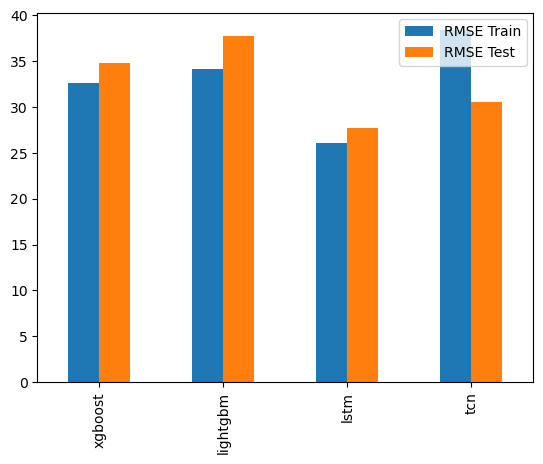

In [22]:
import mlflow
import mlflow.sklearn  # or mlflow.pytorch if using PyTorch models
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from src.model.registry import MODEL_REGISTRY
from src.model.evaluate import evaluate_model
from src.model.predict import predict

# 1️⃣ Set MLflow tracking
# Tracking URI now points to SQLite
mlflow.set_tracking_uri("sqlite:////Users/apple/Documents/Projects/NASA-RUL/mlflow.db")

# Ensure artifact folder exists
mlruns_path = "/Users/apple/Documents/Projects/NASA-RUL/mlruns"
os.makedirs(mlruns_path, exist_ok=True)

# Create/get your experiment
mlflow.set_experiment("Model_Comparison")
experiment = mlflow.get_experiment_by_name("Model_Comparison")
print("Experiment ID:", experiment.experiment_id)

# 2️⃣ Initialize storage
models = {}
train_scores = {}
test_scores = {}
predictions = {}

# 3️⃣ Loop over all models
for name, train_fn in MODEL_REGISTRY.items():
    print(f"Starting training: {name}")

    # Start an MLflow run for each model
    with mlflow.start_run(run_name=name) as run:
        # Train the model
        model = train_fn(config, data)
        models[name] = model

        # Log hyperparameters if any
        if hasattr(model, "get_params"):
            mlflow.log_params(model.get_params())
        elif "params" in config.get("models", {}).get(name.lower(), {}):
            mlflow.log_params(config["models"][name.lower()]["params"])

        # Evaluate on training set
        train_rmse = evaluate_model(name, model, data, device)
        train_scores[name] = train_rmse
        mlflow.log_metric("rmse_train", train_rmse)

        # Predict and evaluate on test set
        preds = predict(name, model, data)
        predictions[name] = preds

        # Compute RMSE on test set
        test_rmse = np.sqrt(mean_squared_error(data_rul, preds))
        test_scores[name] = test_rmse
        mlflow.log_metric("rmse_test", test_rmse)

        # Log the model (if scikit-learn)
        try:
            mlflow.sklearn.log_model(model, artifact_path="model")
        except Exception:
            print(f"Could not log model for {name}")

# 4️⃣ Compile results
results_df = pd.DataFrame({
    "RMSE Train": train_scores,
    "RMSE Test": test_scores
})

best_model = results_df["RMSE Test"].idxmin()
print("Best model:", best_model)
print(results_df)

results_df.plot.bar()

In [ ]:
"""from src.experiments.tune_lstm import random_search_lstm

best_model, best_params = random_search_lstm(
    config,
    data,
    n_trials=20
)"""


Trial 1/20


MlflowException: Missing value for required parameter 'value'.

In [ ]:
#torch.save(best_model.state_dict(), "best_lstm_model.pth")

In [ ]:
# How to run MLFlow
# mlflow ui --backend-store-uri /Users/apple/Documents/Projects/NASA-RUL/mlruns --host 127.0.0.1 --port 5000